In [1]:
%cd /content
!rm -rf project
!git clone -q -b develop https://github.com/RoGad/project-to-master-degree.git project
%cd project
!apt-get update -qq
!apt-get -qq install -y xvfb libglu1-mesa-dev libgl1-mesa-dev > /dev/null
!pip -q install gymnasium miniworld open_clip_torch imageio pyvirtualdisplay

/content
/content/project
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00


In [18]:
import os, subprocess, time

import shutil
assert shutil.which("Xvfb")

subprocess.Popen(["Xvfb", ":99", "-screen", "0", "1024x768x24"])
time.sleep(2)
os.environ["DISPLAY"] = ":99"
print("Xvfb запущен, DISPLAY =", os.environ["DISPLAY"])

Xvfb запущен, DISPLAY = :99


In [3]:
import os, shutil, subprocess
print("1) DISPLAY =", repr(os.environ.get("DISPLAY")))
print("2) Xvfb установлен:", shutil.which("Xvfb"))
print("3) Xvfb-процессы:", subprocess.run(["pgrep", "-a", "Xvfb"], capture_output=True, text=True).stdout or "НЕТ")

1) DISPLAY = ':99'
2) Xvfb установлен: /usr/bin/Xvfb
3) Xvfb-процессы: 1959 Xvfb :99 -screen 0 1024x768x24



In [15]:
import os
os.chdir("/content/project")
assert os.path.isdir("src")
assert os.environ.get("DISPLAY")

import os, time
import numpy as np
import torch

import src.config as c
from src.utils import set_seed, save_checkpoint
from src.replay_buffer import ReplayBuffer, collect_random
from src.rssm import RSSM
from src.world_model import train_world_model, sample_batch, imagine_rollout
from src.clip_scorer import CLIPScorer
from src.evaluate import evaluate_all, record_gif, plot_success_rates, plot_training_loss
from src.environment import make_env, preprocess, to_image

set_seed()
print("device:", c.DEVICE)

device: cuda


In [5]:
t0 = time.time()
buf = collect_random(ReplayBuffer(), c.COLLECT_EPISODES)
print(f"эпизодов: {len(buf)} | переходов: {buf.num_transitions()} | "
      f"успехов случайной политики: {buf.num_successes()}/{len(buf)} | {time.time()-t0:.0f} c")

Falling back to num_samples=4
Falling back to num_samples=4
эпизодов: 300 | переходов: 9538 | успехов случайной политики: 154/300 | 14 c


In [6]:
wm = RSSM().to(c.DEVICE)
history = []
t0 = time.time()
train_world_model(wm, buf, history=history)
print(f"обучение заняло {time.time()-t0:.0f} c")
save_checkpoint(wm, "checkpoints/world_model.pt")
print("чекпоинт: checkpoints/world_model.pt")

шаг    0 | recon 77.4 | kl 3.00 | reward 0.0069
шаг  200 | recon 12.8 | kl 3.45 | reward 0.0001
шаг  400 | recon 10.5 | kl 3.95 | reward 0.0002
шаг  600 | recon 9.4 | kl 3.68 | reward 0.0003
шаг  800 | recon 10.7 | kl 3.80 | reward 0.0057
шаг 1000 | recon 8.0 | kl 3.54 | reward 0.0015
шаг 1200 | recon 8.0 | kl 3.39 | reward 0.0002
шаг 1400 | recon 6.8 | kl 3.37 | reward 0.0001
шаг 1600 | recon 9.1 | kl 3.52 | reward 0.0023
шаг 1800 | recon 6.6 | kl 3.38 | reward 0.0002
шаг 2000 | recon 7.2 | kl 3.31 | reward 0.0002
шаг 2200 | recon 5.4 | kl 3.30 | reward 0.0001
шаг 2400 | recon 7.5 | kl 3.37 | reward 0.0016
шаг 2600 | recon 6.0 | kl 3.31 | reward 0.0002
шаг 2800 | recon 5.8 | kl 3.34 | reward 0.0032
шаг 2999 | recon 7.4 | kl 3.44 | reward 0.0028
обучение заняло 404 c
чекпоинт: checkpoints/world_model.pt


Falling back to num_samples=4
Falling back to num_samples=4


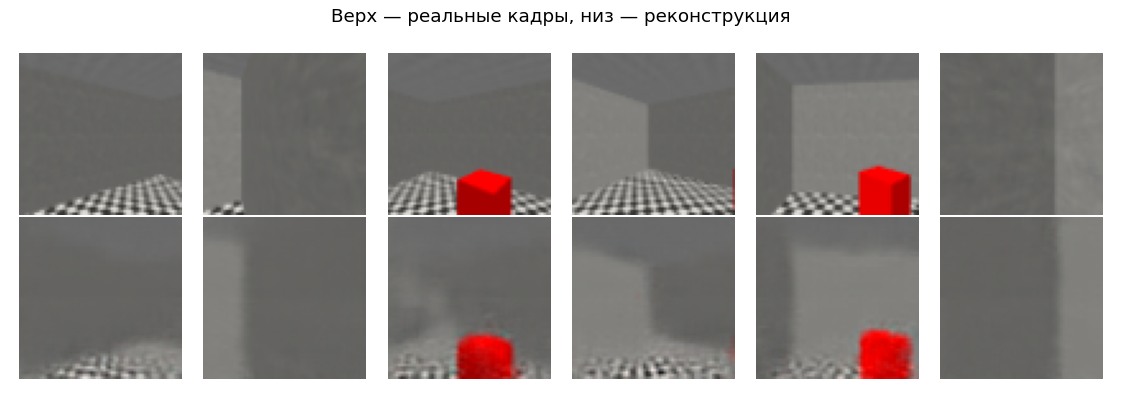

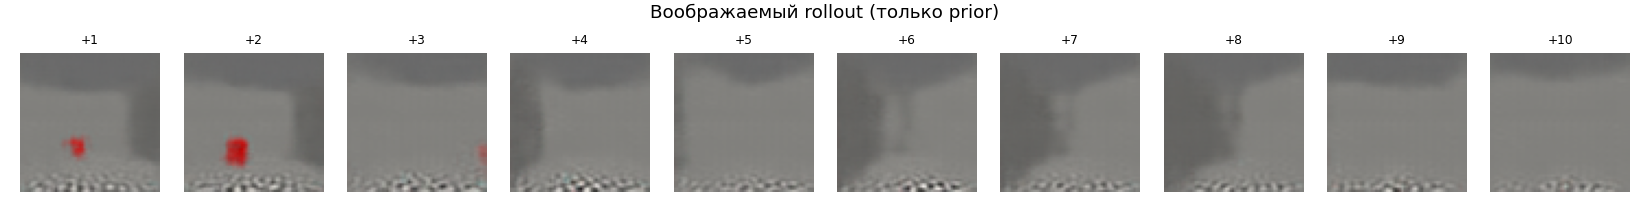

In [7]:
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display as ipd
os.makedirs("results/plots", exist_ok=True)

fr, pa, rw = sample_batch(buf)
with torch.no_grad():
    B, L = fr.shape[:2]
    emb = wm.encode(fr.reshape(B * L, 3, c.IMG_SIZE, c.IMG_SIZE)).reshape(B, L, -1)
    deter, stoch = wm.initial_state(B)
    for t in range(L):
        deter, stoch, _, _ = wm.obs_step(stoch, pa[:, t], deter, emb[:, t])
    recon = wm.decode(deter, stoch)
n = 6
fig, ax = plt.subplots(2, n, figsize=(n * 1.7, 3.6))
for i in range(n):
    ax[0, i].imshow(to_image(fr[i, -1])); ax[0, i].axis("off")
    ax[1, i].imshow(to_image(recon[i])); ax[1, i].axis("off")
plt.suptitle("Верх — реальные кадры, низ — реконструкция")
plt.tight_layout(); plt.savefig("results/plots/recon.png", dpi=110); plt.close()

env = make_env(); obs, _ = env.reset(seed=5); env.close()
with torch.no_grad():
    deter, stoch = wm.initial_state(1)
    zero = torch.zeros(1, c.NUM_ACTIONS, device=c.DEVICE)
    deter, stoch, _, _ = wm.obs_step(stoch, zero, deter, wm.encode(preprocess(obs)))
    seqs = torch.randint(0, c.NUM_ACTIONS, (1, c.HORIZON), device=c.DEVICE)
    states = imagine_rollout(wm, deter, stoch, seqs)
    dreams = [to_image(wm.decode(d, s)[0]) for d, s in states]
fig, ax = plt.subplots(1, len(dreams), figsize=(len(dreams) * 1.5, 1.9))
for i, im in enumerate(dreams):
    ax[i].imshow(im); ax[i].axis("off"); ax[i].set_title(f"+{i+1}", fontsize=8)
plt.suptitle("Воображаемый rollout (только prior)")
plt.tight_layout(); plt.savefig("results/plots/imagination.png", dpi=110); plt.close()

ipd(IPImage("results/plots/recon.png"))
ipd(IPImage("results/plots/imagination.png"))

In [8]:
scorer = CLIPScorer()
t0 = time.time()
df = evaluate_all(wm, scorer)
df.to_csv("results/table.csv", index=False)
print(f"\n{len(c.EVAL_SEEDS)} сидов x {c.EVAL_EPISODES} эпизодов, лимит {c.EVAL_MAX_STEPS} шагов | {time.time()-t0:.0f} c")
df

open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Falling back to num_samples=4
Falling back to num_samples=4
random                           success_rate = 0.42
Falling back to num_samples=4
Falling back to num_samples=4
world-model planning (no VLM)    success_rate = 0.71
Falling back to num_samples=4
Falling back to num_samples=4
world-model planning + VLM       success_rate = 0.58

3 сидов x 15 эпизодов, лимит 15 шагов | 1860 c


,method,success_rate,std
0,random,0.422222,0.031427
1,world-model planning (no VLM),0.711111,0.031427
2,world-model planning + VLM,0.577778,0.113312


Falling back to num_samples=4
Falling back to num_samples=4
VLM   seed 77: success=True  шагов=1


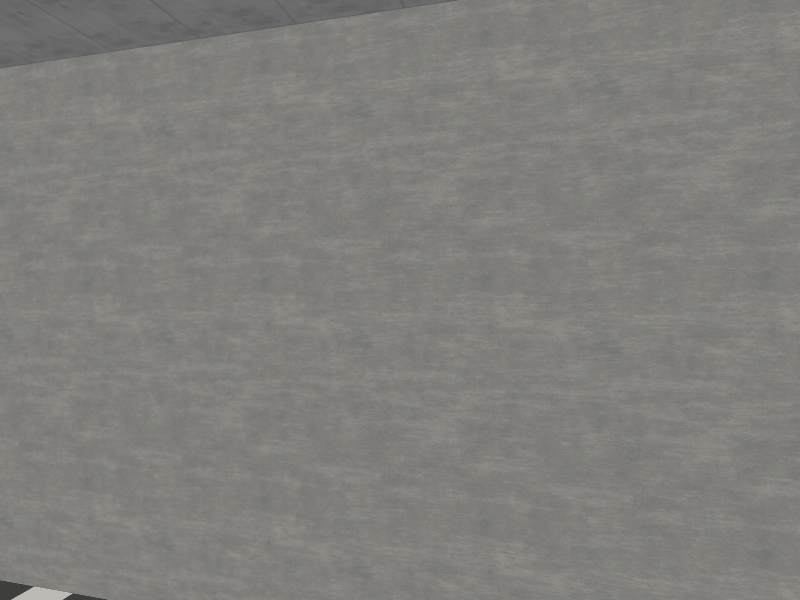

Falling back to num_samples=4
Falling back to num_samples=4
VLM   seed 123: success=False  шагов=15
Falling back to num_samples=4
Falling back to num_samples=4
VLM   seed 5: success=False  шагов=15
Falling back to num_samples=4
Falling back to num_samples=4
Reward seed 77: success=True  шагов=1


In [9]:
shown = False
for seed in [77, 123, 5]:
    ok, n = record_gif(wm, "vlm", seed=seed, path=f"results/gifs/vlm_{seed}.gif", scorer=scorer)
    print(f"VLM   seed {seed}: success={ok}  шагов={n}")
    if ok and not shown:
        ipd(IPImage(f"results/gifs/vlm_{seed}.gif")); shown = True
ok, n = record_gif(wm, "reward", seed=77, path="results/gifs/reward_77.gif")
print(f"Reward seed 77: success={ok}  шагов={n}")

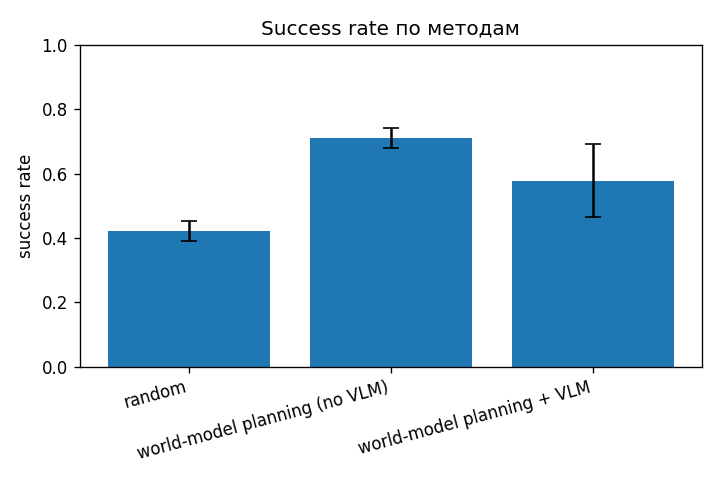

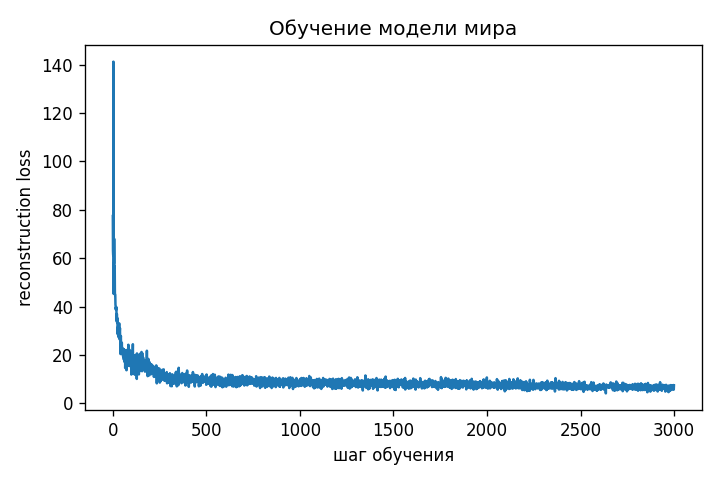

In [10]:
plot_success_rates(df, "results/plots/success_rates.png")
plot_training_loss(history, "results/plots/training_loss.png")
ipd(IPImage("results/plots/success_rates.png"))
ipd(IPImage("results/plots/training_loss.png"))

In [11]:
!zip -qr artifacts.zip checkpoints results
from google.colab import files
files.download("artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Falling back to num_samples=4
Falling back to num_samples=4
H= 5  world-model planning (no VLM)    success_rate = 0.67 ± 0.05
Falling back to num_samples=4
Falling back to num_samples=4
H= 5  world-model planning + VLM       success_rate = 0.58 ± 0.19


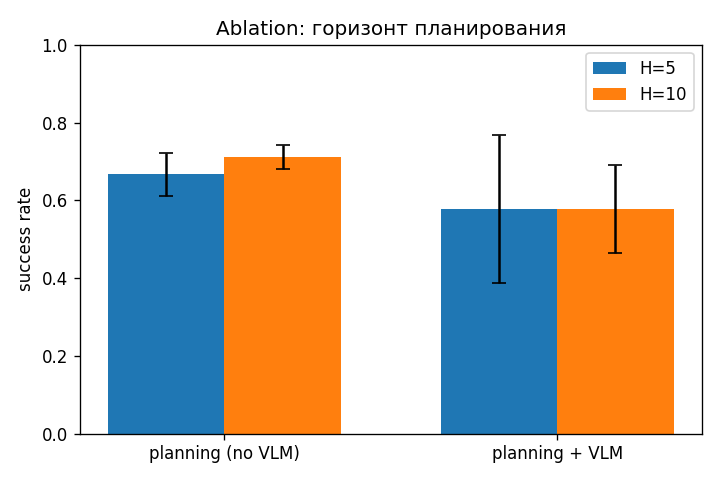

,horizon,method,success_rate,std
2,5,world-model planning (no VLM),0.666667,0.054433
0,10,world-model planning (no VLM),0.711100,0.031400
3,5,world-model planning + VLM,0.577778,0.191163
1,10,world-model planning + VLM,0.577800,0.113300


In [12]:
import numpy as np
import pandas as pd
from src.evaluate import evaluate_method, METHOD_NAMES
from src.utils import set_seed

HORIZONS = [5]
known_h10 = [
    (10, METHOD_NAMES["reward"], 0.7111, 0.0314),
    (10, METHOD_NAMES["vlm"],    0.5778, 0.1133),
]

rows = [] if 10 in HORIZONS else list(known_h10)
for H in HORIZONS:
    for method in ["reward", "vlm"]:
        c.HORIZON = H
        set_seed()
        sc = scorer if method == "vlm" else None
        per_seed = evaluate_method(wm, method, sc)
        m, s = float(np.mean(per_seed)), float(np.std(per_seed))
        rows.append((H, METHOD_NAMES[method], m, s))
        print(f"H={H:2d}  {METHOD_NAMES[method]:32s} success_rate = {m:.2f} ± {s:.2f}")
c.HORIZON = 10

abl = pd.DataFrame(rows, columns=["horizon", "method", "success_rate", "std"]).sort_values(["method", "horizon"])
abl.to_csv("results/ablation_horizon.csv", index=False)

import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display as ipd
fig, ax = plt.subplots(figsize=(6, 4))
width = 0.35
methods = [METHOD_NAMES["reward"], METHOD_NAMES["vlm"]]
for k, H in enumerate(sorted(abl["horizon"].unique())):
    sub = abl[abl["horizon"] == H].set_index("method").loc[methods]
    ax.bar(np.arange(len(methods)) + k * width, sub["success_rate"], width,
           yerr=sub["std"], capsize=4, label=f"H={H}")
ax.set_xticks(np.arange(len(methods)) + width / 2)
ax.set_xticklabels(["planning (no VLM)", "planning + VLM"])
ax.set_ylabel("success rate"); ax.set_ylim(0, 1); ax.legend(); ax.set_title("Ablation: горизонт планирования")
plt.tight_layout(); plt.savefig("results/plots/ablation_horizon.png", dpi=120); plt.close()
ipd(IPImage("results/plots/ablation_horizon.png"))
abl